In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./new_code_results.csv')

In [3]:
print(df.describe())

           Prob  MAE_overall  MAE_reward_minus_1  MAE_reward_0  MAPE_positive
count  5.000000     5.000000            5.000000      5.000000       5.000000
mean   0.500000     0.012305            0.031612      0.009166       1.178712
std    0.316228     0.001406            0.033344      0.007646       0.562525
min    0.100000     0.009821            0.004416      0.004354       0.718449
25%    0.300000     0.012575            0.009508      0.004965       0.874839
50%    0.500000     0.012887            0.025436      0.006620       0.921945
75%    0.700000     0.013114            0.030694      0.007208       1.256438
max    0.900000     0.013127            0.088005      0.022684       2.121892


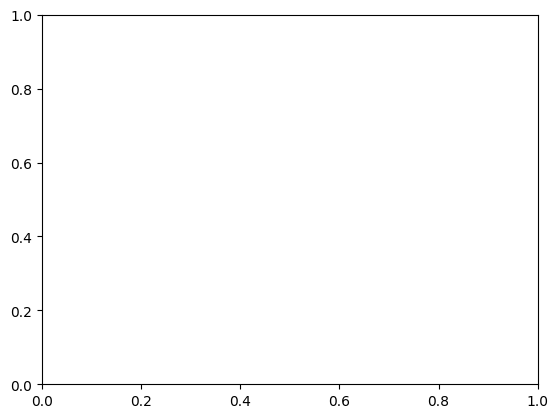

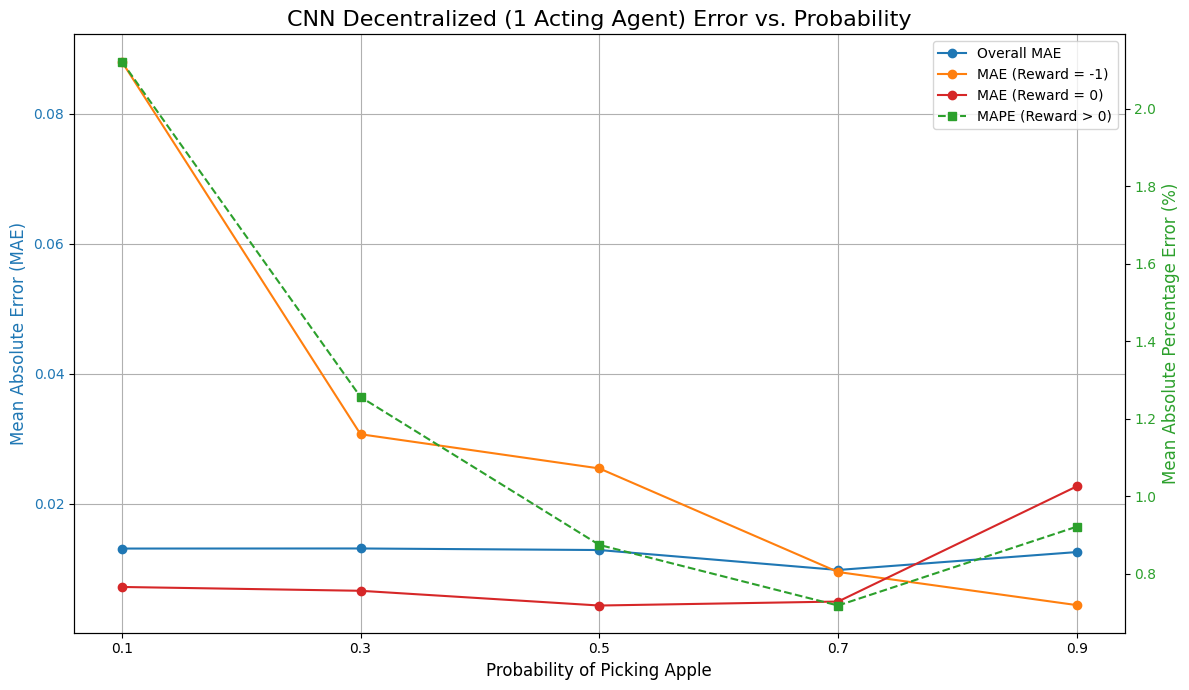

In [7]:
# plot error against the probabilities of the df
import matplotlib.pyplot as plt
# sort df by prob
plot, subplot = plt.subplots()
df = df.sort_values(by='Prob')
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot the MAE values on the primary (left) y-axis
ax1.plot(df['Prob'], df['MAE_overall'], marker="o", label="Overall MAE", color='tab:blue')
ax1.plot(df['Prob'], df['MAE_reward_minus_1'], marker="o", label="MAE (Reward = -1)", color='tab:orange')
ax1.plot(df['Prob'], df['MAE_reward_0'], marker="o", label="MAE (Reward = 0)", color='tab:red')
ax1.set_xlabel("Probability of Picking Apple", fontsize=12)
ax1.set_ylabel("Mean Absolute Error (MAE)", color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Create a second y-axis for the MAPE values
ax2 = ax1.twinx()
ax2.plot(df['Prob'], df['MAPE_positive'], marker="s", linestyle='--', label="MAPE (Reward > 0)", color='tab:green')
ax2.set_ylabel("Mean Absolute Percentage Error (%)", color='tab:green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends from both axes for clarity
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.title("CNN Decentralized (1 Acting Agent) Error vs. Probability", fontsize=16)
plt.xticks(df['Prob'])
fig.tight_layout()
plt.show()
